### Импорт библиотеки и загрузка датасета

In [1]:
import pandas as pd
df = pd.read_csv("Исходники\Churn.csv")

<>:2: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:2: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\a1v2f5\AppData\Local\Temp\ipykernel_29008\2938476264.py:2: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = pd.read_csv("Исходники\Churn.csv")


Column Name	     |             Description	                 |       Data Type    |      Example Value
_________________________________________________________________________________________________________
CustomerID	     |     Уникальный идентификатор для          |         int	      |     1, 2, …, 100000
                             каждого клиента

Age	             |   Возраст клиента (range: 18–80)	         |         int	      |          51
Gender           |   	       Пол покупателя  	             |        string	  |     Male / Female / Other
Tenure           |  Количество месяцев, в течение которых    |         int	      |             58
                 |    клиент работает в компании (1-72)      |                    |
                 |                                           |                    |
MonthlyCharges	 | Сумма ежемесячного счета в долларах США 	 |        float	      |            95.92
                 |       (realistic range: ~10–150)          |                    |
                 |                                                                |
TotalCharges     |       Общая сумма, взимаемая за период    |        float	      |           5530.46
                            пребывания в должности
                 |   (Tenure × MonthlyCharges + small noise) |                    |
Contract	     |              Тип контакта	             |        string      |   Month-to-month / One year /                                        |                                           |                    |           Two year
                 |                                           |                    |
PaymentMethod	 |         Предпочитаемый способ оплаты	     |        string	  |     Electronic check / Mailed  check /                               |                                           |                    |       Bank transfer / Credit card
Churn	         |        Был ли клиент взбудоражен  	     |        string	  |           Yes / No
                 |            (целевая переменная)           |                    |

### Начало обработки

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             89976 non-null   float64
 2   Gender          95099 non-null   str    
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  92996 non-null   float64
 5   Contract        100000 non-null  str    
 6   PaymentMethod   92061 non-null   str    
 7   TotalCharges    94474 non-null   float64
 8   Churn           100000 non-null  str    
dtypes: float64(3), int64(2), str(4)
memory usage: 6.9 MB


При помощи info я просмотрел информацию про датасет:
>В колонках Age, Gender, MonthlyCharges, PaymentMethod, TotalCharges присутствуют пустые значения. 

>Колонки Gender, Contract, PaymentMethod, Churn имеют тип данных - str. Что непозволяет их анализировать пока что.

In [3]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,89976.000000,100000.000000,92996.000000,94474.000000
mean,50000.500000,49.002178,36.527090,80.012627,2926.412472
std,28867.657797,18.178024,20.789552,40.484270,2387.311942
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.760000,963.642500
50%,50000.500000,49.000000,37.000000,80.145000,2269.120000
75%,75000.250000,65.000000,54.000000,115.082500,4396.635000
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


Всё сработало правильно, колонок, где тип str нет в таблице. Они не проанализированы. Теперь я начну обработку пропусков, чтобы затем начать анализировать. 

### Пропуски

Сначала просмотрю пустые значения при помощи seaborn.

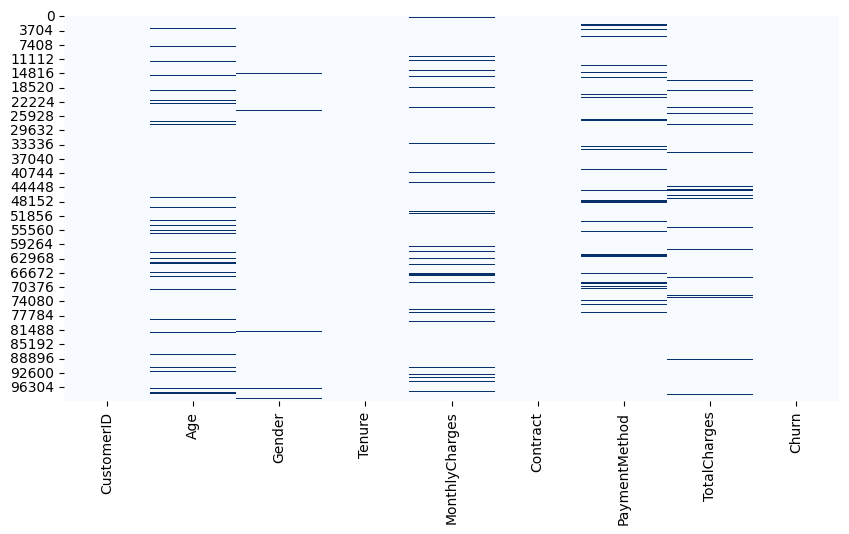

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar = False, cmap = 'Blues')
plt.show()

Много... Тут много пропусков...

In [5]:
df.isnull().sum()

CustomerID            0
Age               10024
Gender             4901
Tenure                0
MonthlyCharges     7004
Contract              0
PaymentMethod      7939
TotalCharges       5526
Churn                 0
dtype: int64

Для удобства я вывел список колонок и количества их пропусков в виде таблицы. Исходя из выведенного, я вижу, что больше всего пропусков в колонке Age, меньше всего - в Gender.

In [6]:
df['Age'].unique()

array([56., 69., 46., 32., 60., 25., nan, 38., 75., 40., 28., 41., 70.,
       53., 57., 20., 39., 19., 61., 47., 55., 77., 50., 29., 78., 42.,
       44., 76., 80., 59., 33., 79., 64., 68., 72., 74., 26., 35., 21.,
       31., 67., 43., 37., 45., 52., 34., 23., 71., 51., 27., 48., 65.,
       62., 58., 18., 24., 22., 54., 30., 49., 66., 36., 73., 63.])

Для колонки Age я использую медиану, так как тут могут быть выбросы, к которым чувствительно среднее значение.

In [7]:
df['Age'].median()

np.float64(49.0)

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\a1v2f5\AppData\Local\Temp\ipykernel_29008\813512978.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(df['Age'].median(), inplace=True)


In [9]:
df['Gender'].unique()

<StringArray>
['Female', 'Male', 'Other', nan]
Length: 4, dtype: str

Я использую моду для колонки Gender, потому что пропуски состовляют менее 5%, и её использование не сильно скажется на датасете.

In [10]:
df['Gender'].mode()

0    Female
Name: Gender, dtype: str

In [11]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

C:\Users\a1v2f5\AppData\Local\Temp\ipykernel_29008\1720792709.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


In [12]:
df['MonthlyCharges'].unique()

array([147.58,  22.54,  52.47, ...,  65.13,  71.51,  85.85],
      shape=(13988,))

Вместо нуля, как было раньше. Я заполняю пропуски в колонке MonthlyCharges значением медианы, чтобы не смещать значения.

In [13]:
df['MonthlyCharges'].median()

np.float64(80.14500000000001)

In [14]:
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].median(), inplace=True)

C:\Users\a1v2f5\AppData\Local\Temp\ipykernel_29008\3848193266.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].median(), inplace=True)


In [15]:
df['PaymentMethod'].unique()

<StringArray>
['Bank transfer', 'Mailed check', nan, 'Credit card', 'Electronic check']
Length: 5, dtype: str

In [16]:
df['PaymentMethod'] = df['PaymentMethod'].fillna('No')

Для колонки PaymentMethod я решил создать новый вариант "Нет". То есть, человек не имеет предпочтений в способе оплаты, и им удобно почти любым способом.

In [17]:
df['TotalCharges'].unique()

array([10052.03,   686.78,   537.88, ...,  2372.33,  6826.55,  3828.6 ],
      shape=(87802,))

Для TotalCharges у нас есть формула, поэтому я заполняю пустые значения используя её. Это код я попросил у нейронки, так как не мог понять, как пройтись по колонкам в каждой строке в тот момент.

In [18]:
import numpy as np

# Рассчитываем значение по формуле
# Добавляем небольшое случайное отклонение (noise), если нужно соответствовать оригиналу
noise = np.random.normal(0, 0.01, size=len(df)) # среднее 0, стандартное отклонение 0.01

# Заполняем только там, где TotalCharges пустой
mask = df['TotalCharges'].isna()

df.loc[mask, 'TotalCharges'] = (
    df.loc[mask, 'Tenure'] * df.loc[mask, 'MonthlyCharges'] + noise[mask]
)

Я закончил заполнять пропуски. Осталось проверить все ли пропуски заполнены теперь.

In [19]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

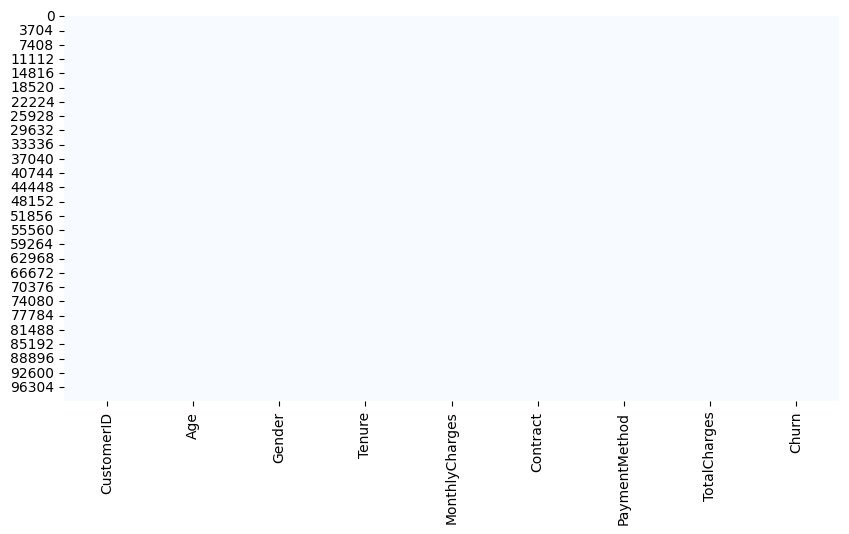

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar = False, cmap = 'Blues')
plt.show()

Как видно, пропусков не осталось. Теперь приступаю к обработке колонок с типом str.

### STR обработка

In [21]:
df['Gender'].unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [22]:
df['Contract'].unique()

<StringArray>
['Two year', 'Month-to-month', 'One year']
Length: 3, dtype: str

In [23]:
df['PaymentMethod'].unique()

<StringArray>
['Bank transfer', 'Mailed check', 'No', 'Credit card', 'Electronic check']
Length: 5, dtype: str

In [24]:
df['Churn'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

По вашему совету использую метод One-hot encoder.

In [25]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Определяем категориальные столбцы
categorical_columns = df.select_dtypes(include=['str']).columns.tolist()

if categorical_columns:
    # Создаем и применяем OneHotEncoder
    ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    encoded_array = ohe.fit_transform(df[categorical_columns].fillna('missing'))
    
    # Создаем DataFrame с закодированными признаками
    encoded_df = pd.DataFrame(
        encoded_array,
        columns=ohe.get_feature_names_out(categorical_columns)
    )
    
    # Объединяем с числовыми столбцами
    numeric_columns = df.select_dtypes(exclude=['str']).columns.tolist()
    df_encoded = pd.concat([df[numeric_columns], encoded_df], axis=1)

Проверяю изменились ли колонки. 

In [26]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   CustomerID                      100000 non-null  int64  
 1   Age                             100000 non-null  float64
 2   Tenure                          100000 non-null  int64  
 3   MonthlyCharges                  100000 non-null  float64
 4   TotalCharges                    100000 non-null  float64
 5   Gender_Male                     100000 non-null  float64
 6   Gender_Other                    100000 non-null  float64
 7   Contract_One year               100000 non-null  float64
 8   Contract_Two year               100000 non-null  float64
 9   PaymentMethod_Credit card       100000 non-null  float64
 10  PaymentMethod_Electronic check  100000 non-null  float64
 11  PaymentMethod_Mailed check      100000 non-null  float64
 12  PaymentMethod_No            

Как видно, колонок стало больше из-за метода One-hot encoder. Точнее некоторые колонки разделились на несколько колонок со значениями 0 и 1. Теперь колонок с str нет. И я могу начать анализировать датасет при помощи матрицы корреляции.

In [27]:
df_encoded.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaymentMethod_No,Churn_Yes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.001960,36.527090,80.021898,2926.486975,0.455110,0.037700,0.252610,0.198240,0.185290,0.320900,0.232040,0.079390,0.331440
std,28867.657797,17.242878,20.789552,39.040777,2385.741989,0.497983,0.190471,0.434511,0.398676,0.388535,0.466825,0.422136,0.270348,0.470733
min,1.000000,18.000000,1.000000,10.000000,-118.430000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25000.750000,35.000000,18.000000,47.470000,964.857500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50000.500000,49.000000,37.000000,80.145000,2270.695000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,75000.250000,63.000000,54.000000,112.500000,4394.355000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,100000.000000,80.000000,72.000000,150.000000,10831.460000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Теперь при использовании describe() все колонки показываются в статистике.

### Матрица корреляции

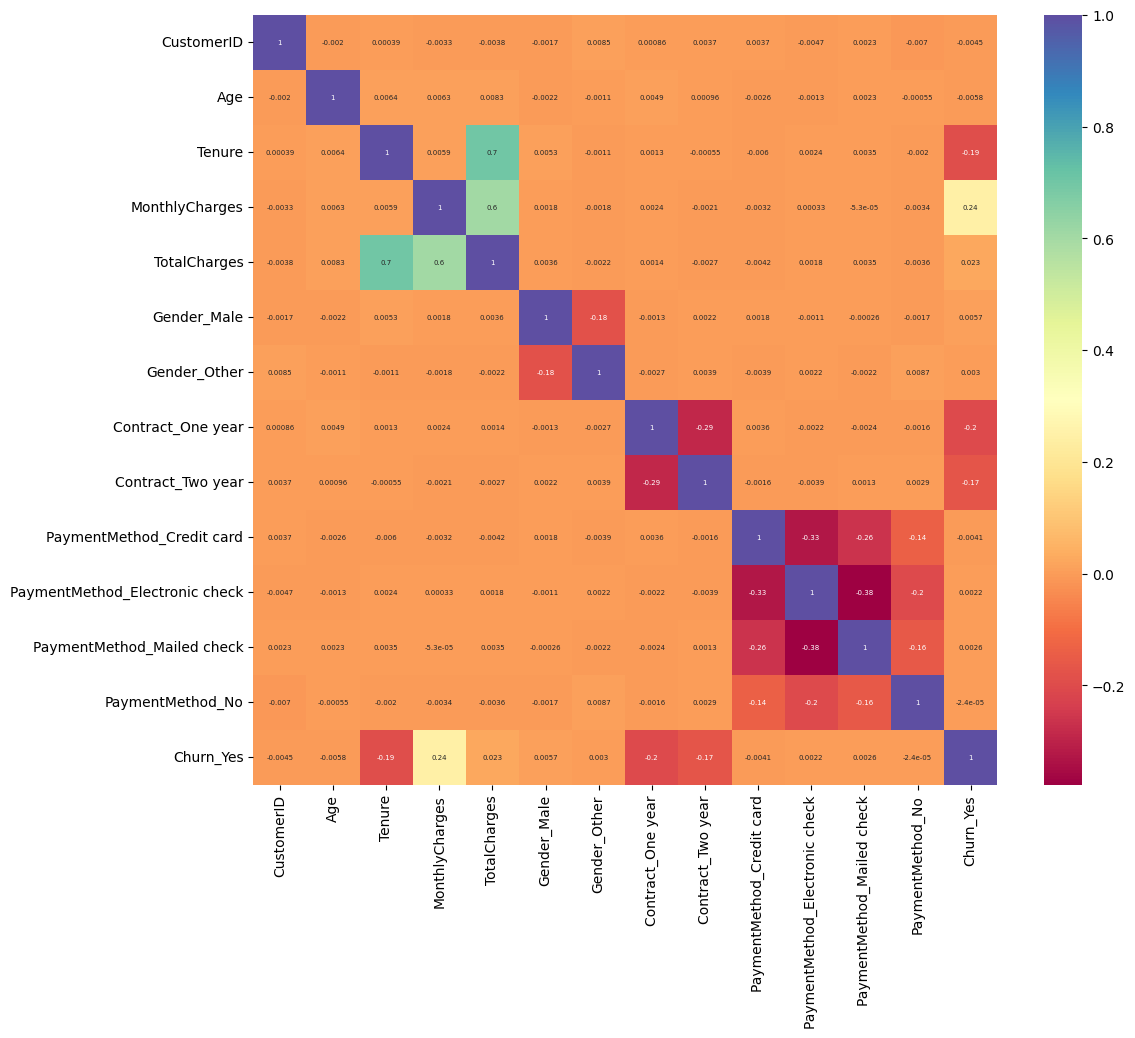

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

#matplotlib
plt.figure(figsize=(12,10))
#seaborn
sns.heatmap(df_encoded.corr(),cmap="Spectral", annot= True, annot_kws={'size':5})
plt.show()

CustomerID содержит только индитификатор и не имеет значения для обучения, а его корреляция со всеми признаками близка к нулю. Но я его оставлю, чтобы программа не считала данные дубликатами.

TotalCharges состоит из значений других колонок (Tenure and MonthlyCharges). У них прямая зависимость, так как чем больше количество месяцев, в течение которых клиент является клиентом компании (Tenure) и чем больше сумма ежемесячного счета в долларах США(MonthleCharges), тем больше общая сумма(TotalCharges). Она не даёт новую информацию и, сама по себе, имеет низкую корреляцию с Churn_Yes, но может привести к переобучению, поэтому я его удалю.

In [29]:
df_encoded.drop(['TotalCharges'], axis=1, inplace = True)

Целевая колонка это Churn_Yes - отток покупателей. Я смотрю на её зависимость с другими колонками. Колонки Age и Gender_Male & Gender_Other слабо влияют на отток, их можно удалить. 

In [30]:
df_encoded.drop(['Age'], axis=1, inplace = True)
df_encoded.drop(['Gender_Male'], axis=1, inplace = True)
df_encoded.drop(['Gender_Other'], axis=1, inplace = True)

Далее я проверяю выбросы в колонках.

In [31]:
df_encoded.describe()

,CustomerID,Tenure,MonthlyCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaymentMethod_No,Churn_Yes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,36.527090,80.021898,0.252610,0.198240,0.185290,0.320900,0.232040,0.079390,0.331440
std,28867.657797,20.789552,39.040777,0.434511,0.398676,0.388535,0.466825,0.422136,0.270348,0.470733
min,1.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25000.750000,18.000000,47.470000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50000.500000,37.000000,80.145000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,75000.250000,54.000000,112.500000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,100000.000000,72.000000,150.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


По таблице видно, что нет огромных разбросов между значениями. На всякий случай я проверю колонки Tenure и MonthlyCharges, остальные не буду, так как в них храняться значения только 0 и 1.

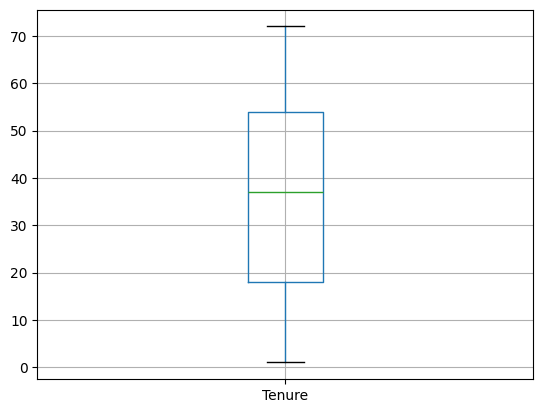

In [32]:
from seaborn import boxplot
boxplot = df_encoded.boxplot(column=['Tenure'])

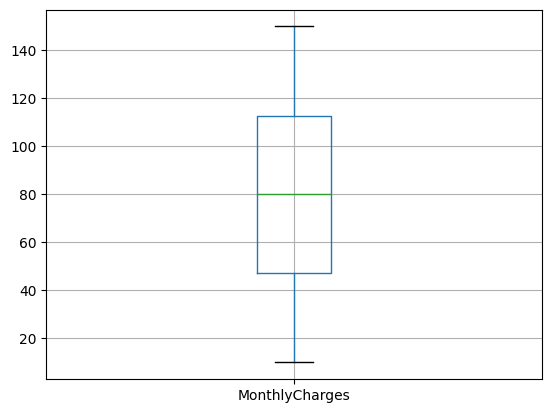

In [33]:
from seaborn import boxplot
boxplot = df_encoded.boxplot(column=['MonthlyCharges'])

В проверенных колонках не оказалось выбросов.

### Дубликаты

In [34]:
df_encoded.duplicated().sum()

np.int64(0)

Проверяю на дубликаты. Дубликатов не найдено, благодаря тому, что я оставил индентификатор.

### Результат

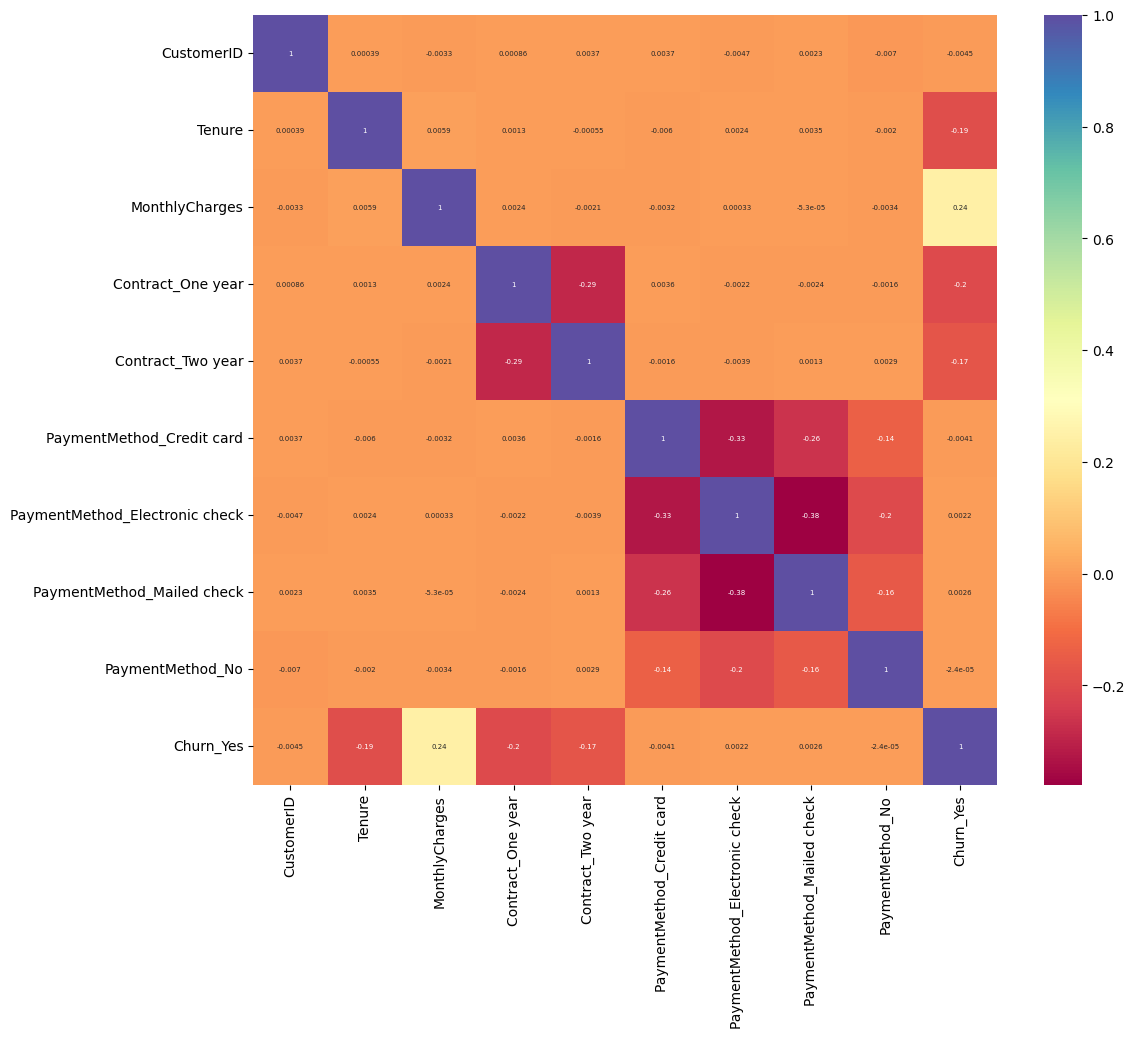

In [35]:
plt.figure(figsize=(12,10))
#seaborn
sns.heatmap(df_encoded.corr(),cmap="Spectral", annot= True, annot_kws={'size':5})
plt.show()

В результате: На целевую колонку Churn_Yes влияют колонки Tenure и (Contract_One year & Contract_Two year). После всех манипуляций матрица практически не изменилась, теперь только отсутствуют колонки которые имели почти нулевую зависимость с целевой колонкой и колонка TotalCharges, которая состояла из друших колонок и не давала новой информации. 